In [ ]:
# STEP 1: DATA GATHERING


!pip install -q ultralytics roboflow

from roboflow import Roboflow
import os


rf = Roboflow(api_key="RmFFjutvfLVxEzsqj2tm")


project = rf.workspace("traffic-signs-in-sri-lanka").project("traffic-signs-in-sri-lanka")
version = project.version(4)



dataset = version.download("yolov8")


print(f"\n✅ Success! Dataset downloaded to: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 129.0 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-signs-in-Sri-Lanka-4 in yolov8:: 100%|██████████| 15892/15892 [00:13<00:00, 1181.69it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ Success! Dataset downloaded to: /content/Traffic-signs-in-Sri-Lanka-4


In [ ]:
# STEP 2: DATA PRE-PROCESSING & CONFIGURATION

import yaml
import os


yaml_file_path = os.path.join(dataset.location, "data.yaml")


with open(yaml_file_path, 'r') as f:
    data_yaml = yaml.safe_load(f)


data_yaml['train'] = os.path.join(dataset.location, 'train', 'images')
data_yaml['val'] = os.path.join(dataset.location, 'valid', 'images')
data_yaml['test'] = os.path.join(dataset.location, 'test', 'images')


with open(yaml_file_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ Configuration verified for {data_yaml['nc']} classes.")
print(f"📍 Training Path: {data_yaml['train']}")

✅ Configuration verified for 76 classes.
📍 Training Path: /content/Traffic-signs-in-Sri-Lanka-4/train/images


In [ ]:
# STEP 3: MODEL INITIALIZATION & TRAINING

from ultralytics import YOLO


model = YOLO('yolov8s.pt')


results = model.train(
    data=yaml_file_path,
    epochs=50,       
    imgsz=640,
    batch=16,           
    device=0,          
    name='sri_lanka_yolo_model',
    save=True
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Traffic-signs-in-Sri-Lanka-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sri_lanka_yolo_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,154,996 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1206.7±604.8 MB/s, size: 246.5 KB)
val: Scanning /content/Traffic-signs-in-Sri-Lanka-4/valid/labels.cache... 714 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 714/714 142.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 3.7it/s 12.3s
                   all        714       1033      0.941      0.923      0.974        0.7
                0SD-03          2          2      0.914          1      0.995      0.845
                APR-09          3          3          1      0.759      0.995      0.747
                APR-10         10         10          1      0.727      0.995      0.665
                APR-11         13         13          1      0.714      0.914      0.627
                APR-12 

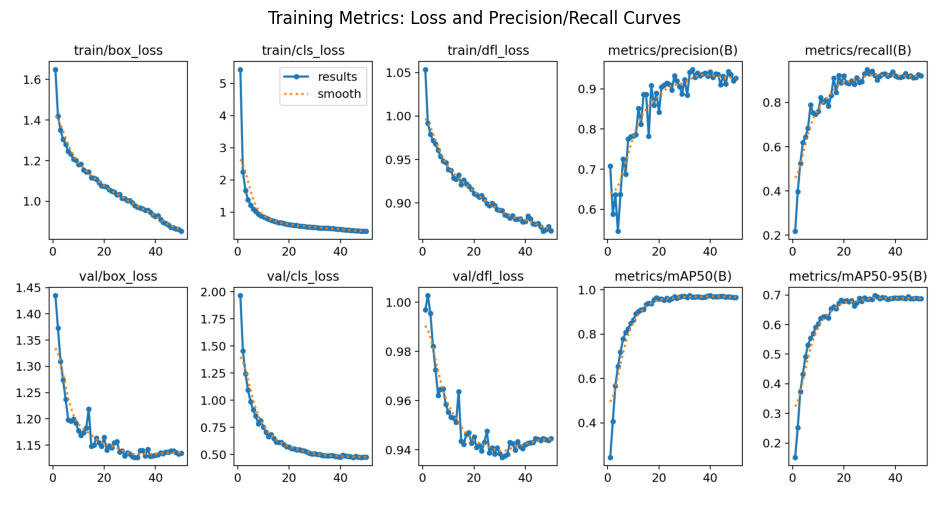

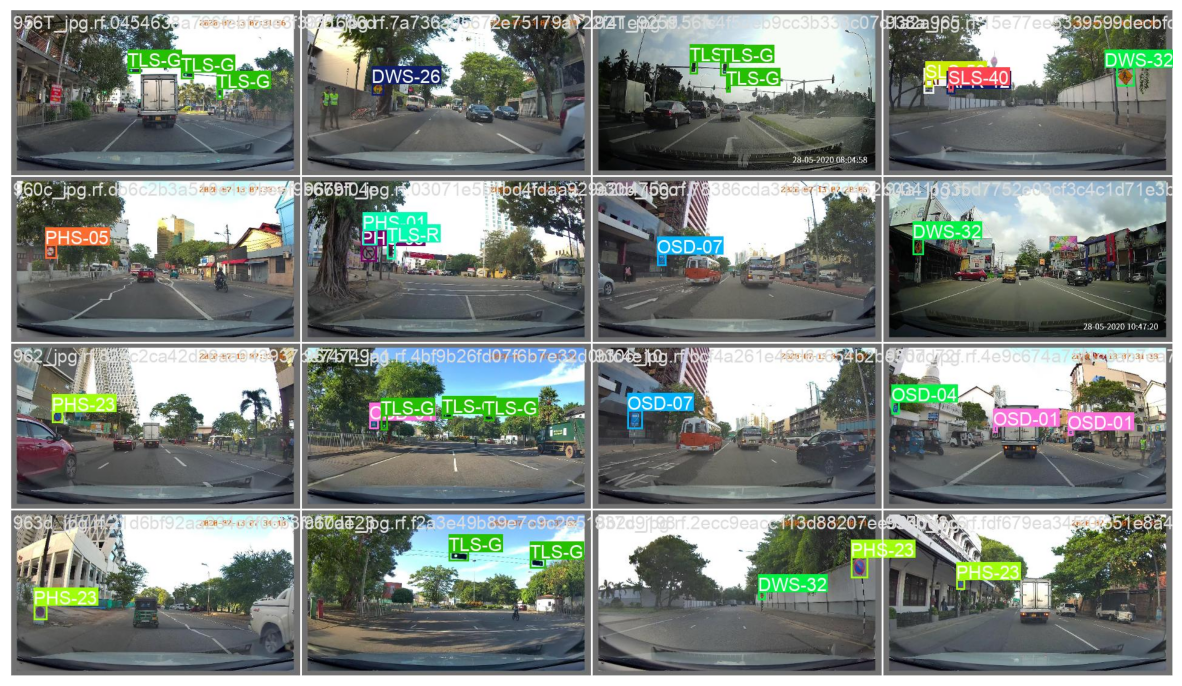

In [ ]:
# STEP 4: EVALUATION
import matplotlib.pyplot as plt
import cv2
import os

metrics = model.val()
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.3f}")


# YOLO saves these as 'results.png' in your project folder
results_path = f'runs/detect/sri_lanka_yolo_model/results.png'
if os.path.exists(results_path):
    img = cv2.imread(results_path)
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Training Metrics: Loss and Precision/Recall Curves")
    plt.show()

# 3. View Sample Predictions from the Validation Set
val_batch_path = f'runs/detect/sri_lanka_yolo_model/val_batch0_labels.jpg'
if os.path.exists(val_batch_path):
    img = cv2.imread(val_batch_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Running prediction on: /content/Traffic-signs-in-Sri-Lanka-4/test/images/1315d_jpg.rf.e1353843bac279cdd0b0a228581082a8.jpg

image 1/1 /content/Traffic-signs-in-Sri-Lanka-4/test/images/1315d_jpg.rf.e1353843bac279cdd0b0a228581082a8.jpg: 384x640 1 0SD-03, 52.4ms
Speed: 2.1ms preprocess, 52.4ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


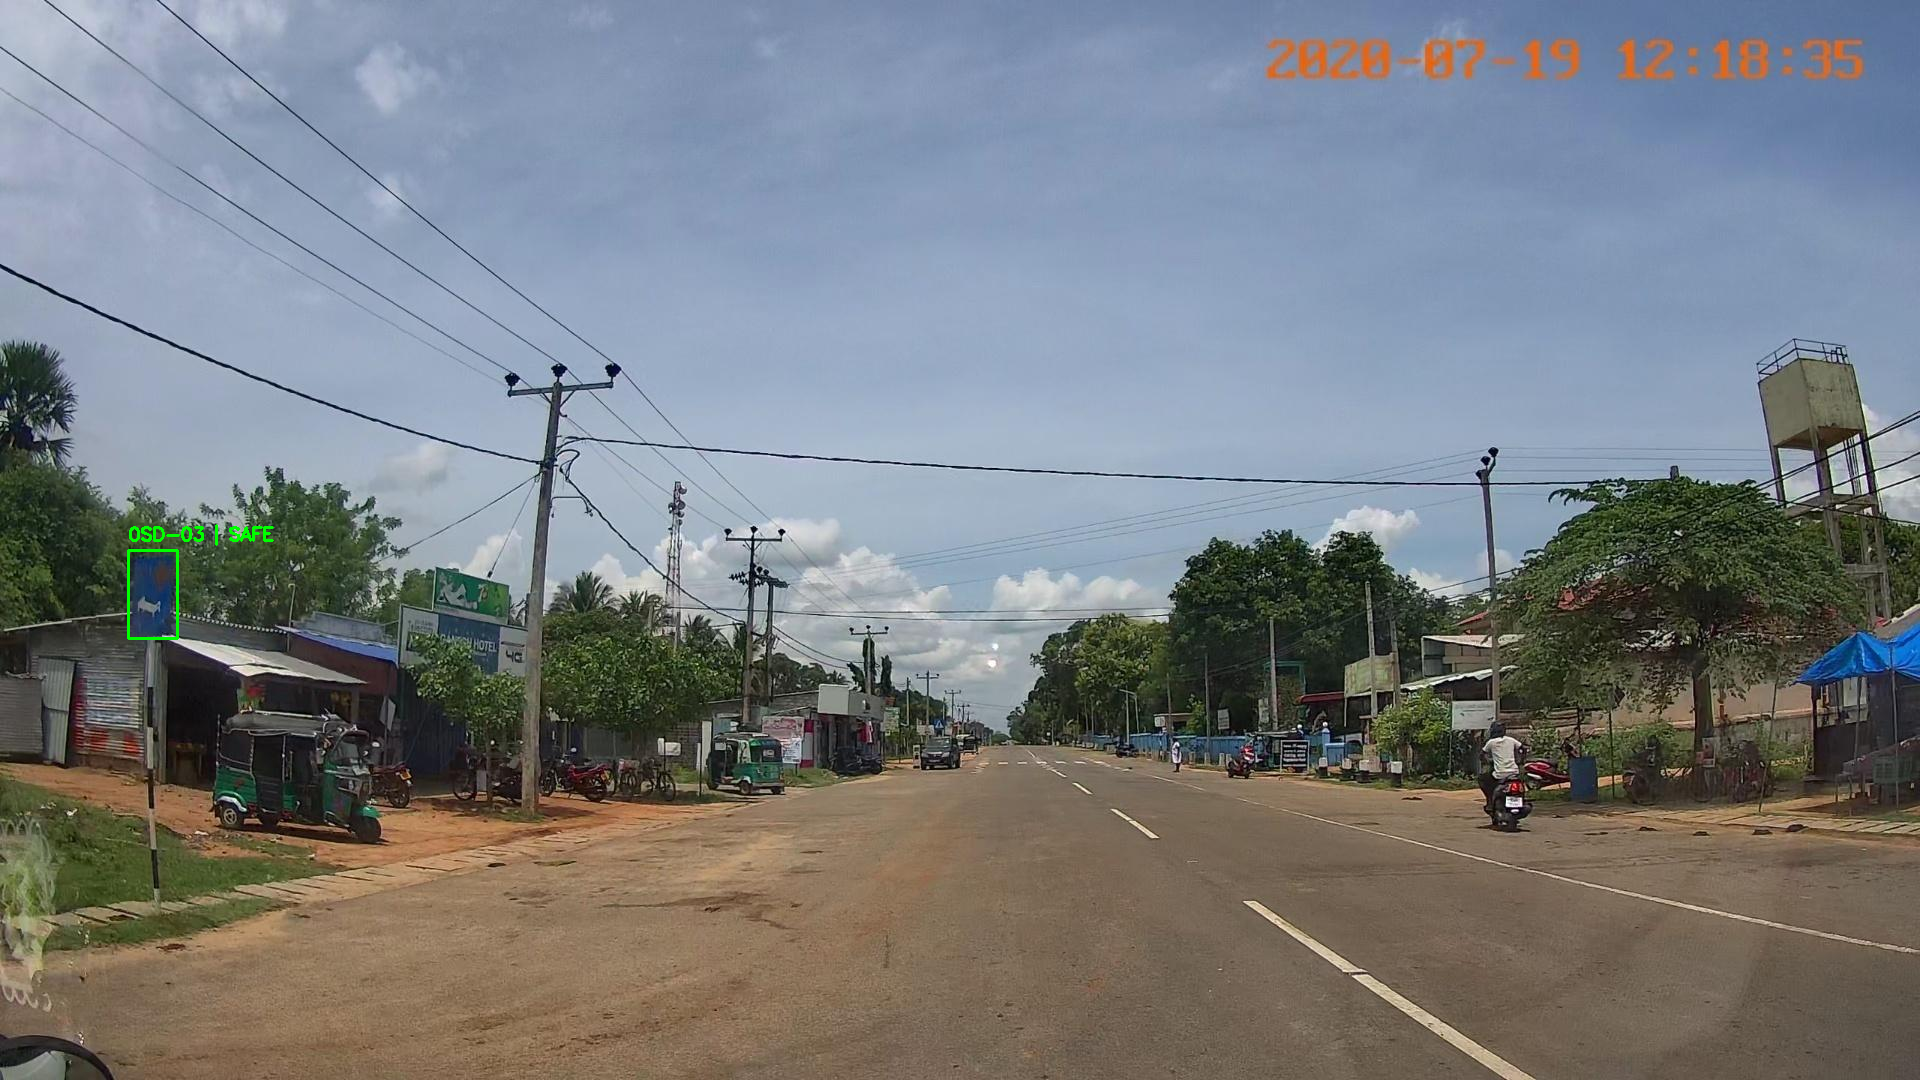

In [10]:
# --- STEP 5: DEPLOYMENT (SMART HUD LOGIC) ---
from ultralytics import YOLO
import cv2
import os
import glob
from google.colab.patches import cv2_imshow

# 1. Load your custom-trained best model
model_path = 'runs/detect/sri_lanka_yolo_model/weights/best.pt'
my_model = YOLO(model_path)

# 2. Simulation Variables (As per your report methodology)
CURRENT_SPEED = 75  # km/h
SCHOOL_ZONE_TIME = True

# 3. Automatically find a real image from your TEST folder
test_image_dir = '/content/Traffic-signs-in-Sri-Lanka-4/test/images/' # Corrected path to images
image_list = glob.glob(os.path.join(test_image_dir, '*.*'))

if len(image_list) == 0:
    print("Error: No images found in the test directory! Check your folder path.")
else:
    test_img = image_list[0] # Pick the first available image
    print(f"Running prediction on: {test_img}")

    # 4. Run Inference
    results = my_model.predict(source=test_img, conf=0.4)

    for r in results:
        frame = r.orig_img.copy()
        for box in r.boxes:
            cls_id = int(box.cls[0])
            label = my_model.names[cls_id]

            # --- PREDICTIVE HAZARD LOGIC ---
            threat_level = "SAFE"
            color = (0, 255, 0) # Green

            # Speed Limit Check
            if "SLS" in label:
                # Extracts numbers from labels like 'SLS-60'
                try:
                    limit = int(''.join(filter(str.isdigit, label)))
                    if CURRENT_SPEED > limit:
                        threat_level = "CRITICAL: SPEEDING"
                        color = (0, 0, 255) # Red
                except: pass

            # School Zone Check (Class DWS-33 is Children)
            elif "DWS-33" in label and SCHOOL_ZONE_TIME:
                threat_level = "MODERATE: SCHOOL ZONE"
                color = (0, 165, 255) # Orange

            # 5. Draw HUD Overlay
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, f"{label} | {threat_level}", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Show Output
        cv2_imshow(frame)

In [12]:
# --- STEP 6: EXTRACT EVALUATION METRICS ---
import os
from ultralytics import YOLO

# 1. Load your best trained model
model = YOLO('runs/detect/sri_lanka_yolo_model/weights/best.pt')

# 2. Run validation on the test set
# This ensures we evaluate on unseen data for unbiased results
results = model.val(data=yaml_file_path, split='test')

# 3. Print the Summary Metrics
print("\n--- GLOBAL PERFORMANCE METRICS ---")
print(f"Precision: {results.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall:    {results.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP 50:    {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP 50-95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")

# 4. Print Per-Class Performance (Optional, for your report table)
print("\n--- PER-CLASS PERFORMANCE ---")
if hasattr(results, 'class_stats') and results.class_stats.size > 0:
    for i, name in enumerate(results.names.values()):
        # results.class_stats typically stores per-class: [tp, fp, fn, precision, recall, f1, mAP50, mAP]
        # Assuming the columns are in this order for detection tasks
        if results.class_stats.shape[1] >= 7: # Ensure enough columns for P, R, mAP50
            p = results.class_stats[i, 3]   # Precision for class i
            r = results.class_stats[i, 4]   # Recall for class i
            map50 = results.class_stats[i, 6] # mAP50 for class i
            print(f"Class [{name}]: Precision={p:.3f}, Recall={r:.3f}, mAP50={map50:.3f}")
        else:
            print(f"Warning: Insufficient columns in results.class_stats for class {name}.")
else:
    print("Per-class statistics not available or empty in 'results.class_stats'.")


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,154,996 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1879.9±988.4 MB/s, size: 263.4 KB)
val: Scanning /content/Traffic-signs-in-Sri-Lanka-4/test/labels.cache... 79 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 79/79 23.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.1s
                   all         79        128      0.836      0.887      0.913       0.64
                0SD-03          2          2      0.843          1      0.995      0.671
                APR-10          1          1      0.726          1      0.995      0.796
                APR-11          2          2      0.826          1      0.995      0.846
                APR-12          3          3      0.998          1      0.995      0.697
                DWS-01         

In [13]:
from google.colab import files

# The confusion matrix shows where the model gets confused between sign types
if os.path.exists('runs/detect/sri_lanka_yolo_model/confusion_matrix.png'):
    files.download('runs/detect/sri_lanka_yolo_model/confusion_matrix.png')
    print("Confusion Matrix downloaded for your Results chapter.")

# The F1_Curve shows the balance between Precision and Recall
if os.path.exists('runs/detect/sri_lanka_yolo_model/F1_curve.png'):
    files.download('runs/detect/sri_lanka_yolo_model/F1_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Confusion Matrix downloaded for your Results chapter.


In [14]:
import os
from google.colab import files

# Zip the important charts
!zip -r report_images.zip runs/detect/sri_lanka_yolo_model/*.png runs/detect/sri_lanka_yolo_model/*.jpg

# Download the zip file
files.download('report_images.zip')

  adding: runs/detect/sri_lanka_yolo_model/BoxF1_curve.png (deflated 8%)
  adding: runs/detect/sri_lanka_yolo_model/BoxP_curve.png (deflated 11%)
  adding: runs/detect/sri_lanka_yolo_model/BoxPR_curve.png (deflated 15%)
  adding: runs/detect/sri_lanka_yolo_model/BoxR_curve.png (deflated 10%)
  adding: runs/detect/sri_lanka_yolo_model/confusion_matrix_normalized.png (deflated 30%)
  adding: runs/detect/sri_lanka_yolo_model/confusion_matrix.png (deflated 30%)
  adding: runs/detect/sri_lanka_yolo_model/results.png (deflated 8%)
  adding: runs/detect/sri_lanka_yolo_model/labels.jpg (deflated 36%)
  adding: runs/detect/sri_lanka_yolo_model/train_batch0.jpg (deflated 5%)
  adding: runs/detect/sri_lanka_yolo_model/train_batch17880.jpg (deflated 11%)
  adding: runs/detect/sri_lanka_yolo_model/train_batch17881.jpg (deflated 12%)
  adding: runs/detect/sri_lanka_yolo_model/train_batch17882.jpg (deflated 10%)
  adding: runs/detect/sri_lanka_yolo_model/train_batch1.jpg (deflated 5%)
  adding: runs/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from google.colab import files

# Path to your best performing model
model_path = 'runs/detect/sri_lanka_yolo_model/weights/best.pt'

# Trigger the download
if os.path.exists(model_path):
    files.download(model_path)
    print("Download started: best.pt")
else:
    print("Error: Model file not found. Check if training finished successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: best.pt
